# **PORTUGESE STUDENTS**

## Imports

In [1089]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from models import train_linear_model, train_logistic_model
from sklearn.metrics import accuracy_score
from data import category_split, balance_feature, frame_status_info
from evaluation import evaluate_model, plot_model_acc_and_fscore, display_model_weights, evaluate_model_thresholded_regression, evaluate_model_classifier

## Settings

In [1090]:
DATA_RELATIVE_PATH = "data/student_portugal/combined_noDup_processed.csv"

TARGET_COLUMN = "G1"
TARGET_OPERTOR = "<" #Does not change the training, only splits
TARGET_VALUE = 10


RANDOM_SEED = None
SPLIT_PERCENTAGE_TESTING = 0.05823743935065637 #0.3

BALANCE_DATA = False
BALANCE_QUERY = TARGET_COLUMN + " " + TARGET_OPERTOR + " " + str(TARGET_VALUE)
BALANCE_QUERY_NON_TARGET_PERCENTAGE = 0.50


REGULARIZER_WEIGTH = 0.04531440462081082 #0.01
#MODEL_THERESHOLD_REG = TARGET_VALUE
MODEL_THERESHOLD_LOG = 0.353395129431884 #0.5

DEBUG_MODE = True


## Loading the Data

In [1091]:
# Load dataset
data_file = os.path.join(os.getcwd(), DATA_RELATIVE_PATH)
df = pd.read_csv(data_file)
print("Loaded datafile")
print(df.shape)

Loaded datafile
(662, 45)


# Data processing

### Irrelevant data

In [1092]:
#Remove constant columns
df = df.loc[:, df.nunique() > 1]
print(df.shape)

(662, 45)


### Identical Data

In [1093]:
# Ensure all rows are unique
df = df.drop_duplicates()
print("Removed duplicate rows")
print(df.shape)

Removed duplicate rows
(662, 45)


### Missing data

In [1094]:
# All data is present in this dataframe.

## Feature Processing

In [1095]:
#Remove columns
columns_to_remove = ["school", "sex", "G2", "G3"]
df.drop(columns=columns_to_remove, inplace=True, errors='ignore')
print(df.shape)
print("Percentage of fails: "+str(round((df['G1'] < 10).mean() * 100, 2))+"%")

(662, 41)
Percentage of fails: 36.4%


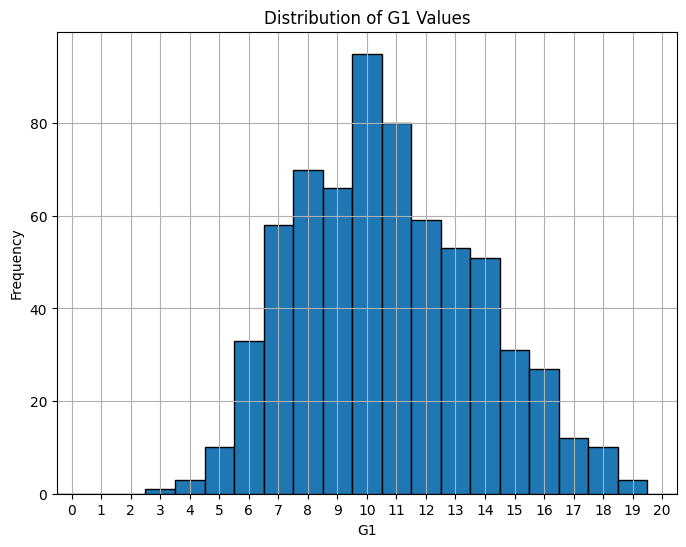

In [1096]:
plt.figure(figsize=(8, 6))
plt.hist(df['G1'], bins=range(0, 22), edgecolor='black', align='left')
plt.title('Distribution of G1 Values')
plt.xlabel('G1')
plt.ylabel('Frequency')
plt.xticks(range(0, 21))  # Show ticks for every integer from 0 to 20
plt.xlim(-0.5, 20.5)      # Set x-axis limits a little wider to center bars
plt.grid(True)
plt.show()

## Splitting data

### Split

In [1097]:
train_df, test_df = train_test_split(df, test_size=SPLIT_PERCENTAGE_TESTING, random_state=RANDOM_SEED)
frame_status_info(train_df, test_df)

Training data shape: (623, 41)
Testing data shape: (39, 41)


### Balance

In [1098]:
if (BALANCE_DATA):
    match_df, no_match_df = category_split(train_df, BALANCE_QUERY)
    train_balanced = balance_feature(match_df, no_match_df, BALANCE_QUERY_NON_TARGET_PERCENTAGE)

## Training

### Preparation

In [1099]:
# Define features and target variable
temp_train : pd.DataFrame = train_balanced if BALANCE_DATA else train_df

frame_status_info(temp_train, test_df)
print("Training percentage:", test_df.shape[0]/temp_train.shape[0])

X_train = temp_train.drop(columns=[TARGET_COLUMN]).values
y_train_reg = temp_train[TARGET_COLUMN]
y_train_cls = (temp_train[TARGET_COLUMN] < TARGET_VALUE).astype(int)

X_test = test_df.drop(columns=[TARGET_COLUMN]).values
y_test_reg = test_df[TARGET_COLUMN]
y_test_cls = (test_df[TARGET_COLUMN] < TARGET_VALUE).astype(int)

Training data shape: (623, 41)
Testing data shape: (39, 41)
Training percentage: 0.06260032102728733


### Execution

In [1100]:
# Train regression models
print("Training RegN")
model_reg_no = train_linear_model(X_train, y_train_reg.values, reg_type=None)  # Standard
print("Training Reg1")
model_reg_l1 = train_linear_model(X_train, y_train_reg.values, reg_type="l1", alpha=REGULARIZER_WEIGTH)  # Lasso
print("Training Reg2")
model_reg_l2 = train_linear_model(X_train, y_train_reg.values, reg_type="l2", alpha=REGULARIZER_WEIGTH)  # Ridge

# Train logistic models
print("Training LogN")
model_log_no = train_logistic_model(X_train, y_train_cls.values, reg_type=None)  # Standard
print("Training Log1")
model_log_l1 = train_logistic_model(X_train, y_train_cls.values, reg_type="l1", alpha=REGULARIZER_WEIGTH)  # Lasso
print("Training Log2")
model_log_l2 = train_logistic_model(X_train, y_train_cls.values, reg_type="l2", alpha=REGULARIZER_WEIGTH)  # Ridge

Training RegN
Training Reg1
Training Reg2
Training LogN
Training Log1
Training Log2


## Evaluation

### Execution

Regression Models:
[Standard Linear Regression] Sample predicted scores: [ 3.93628429e+11 -3.90245900e+11  3.45474426e+11 -1.62734466e+11
  3.57715872e+11  3.12805747e+10  1.69810278e+12 -1.12094017e+12
 -1.05992665e+11  1.36874048e+11]
[Standard Linear Regression] Applied threshold: 10
[Standard Linear Regression] Predicted labels: [False  True False  True False False False  True  True False]
[Standard Linear Regression] Sample true values: [0 0 0 1 0 0 1 1 0 0]
[Standard Linear Regression] Accuracy: 0.5897435897435898
[Standard Linear Regression] F1 Score: 0.42857142857142855


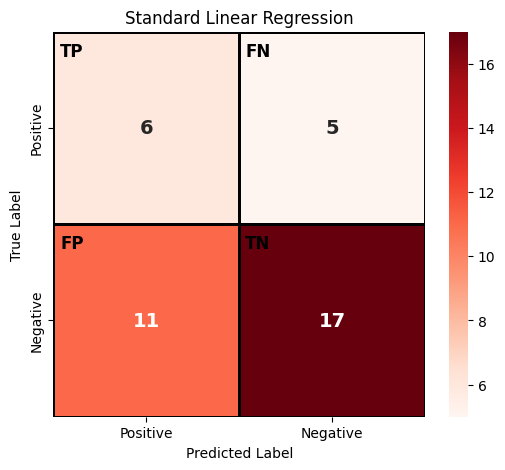

[Lasso Regression] Sample predicted scores: [13.3337432  11.44057694 12.82604969 12.73744842 12.02357074 11.06076429
 11.75707314 11.0811333  11.30601195 12.88243067]
[Lasso Regression] Applied threshold: 10
[Lasso Regression] Predicted labels: [False False False False False False False False False False]
[Lasso Regression] Sample true values: [0 0 0 1 0 0 1 1 0 0]
[Lasso Regression] Accuracy: 0.717948717948718
[Lasso Regression] F1 Score: 0


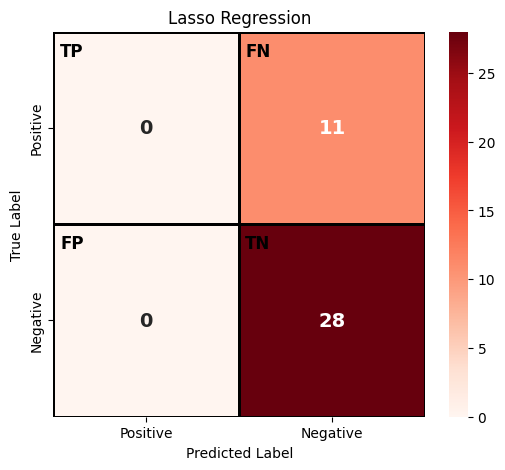

[Ridge Regression] Sample predicted scores: [12.30513784 11.38186969 11.32024958 11.41837093 11.74744753 10.65465987
  8.91641178 10.60629985 11.0721129  11.51738712]
[Ridge Regression] Applied threshold: 10
[Ridge Regression] Predicted labels: [False False False False False False  True False False False]
[Ridge Regression] Sample true values: [0 0 0 1 0 0 1 1 0 0]
[Ridge Regression] Accuracy: 0.7692307692307693
[Ridge Regression] F1 Score: 0.4705882352941177


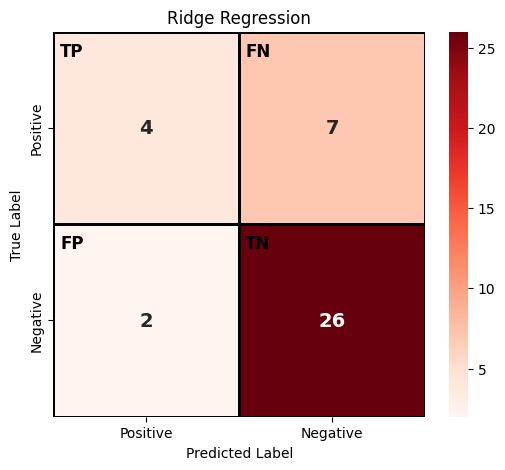

Logistic Models:
[Standard Logistic Regression] Sample predicted probabilities: [1.55388844e-03 6.43280090e-04 6.97696112e-05 3.51615685e-06
 1.52438986e-03 4.48516029e-02 2.53876072e-02 1.25720289e-03
 4.65299879e-02 6.41129337e-04]
[Standard Logistic Regression] Applied threshold: 0.353395129431884
[Standard Logistic Regression] Predicted labels: [False False False False False False False False False False]
[Standard Logistic Regression] Sample true values: [0 0 0 1 0 0 1 1 0 0]
[Standard Logistic Regression] Accuracy: 0.7435897435897436
[Standard Logistic Regression] F1 Score: 0.16666666666666669


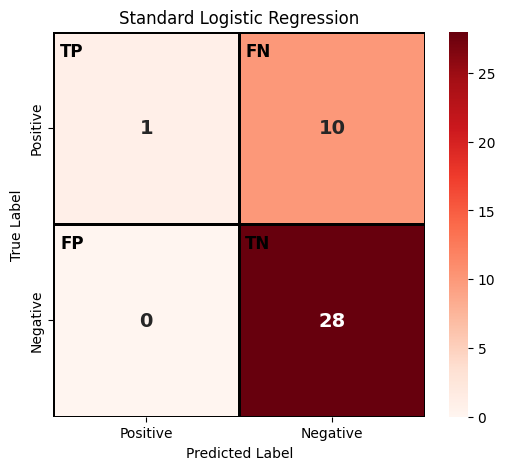

[Lasso Logistic Regression] Sample predicted probabilities: [0.33891253 0.33891253 0.33891253 0.36629907 0.33891253 0.33891253
 0.4830172  0.33891253 0.33891253 0.33891253]
[Lasso Logistic Regression] Applied threshold: 0.353395129431884
[Lasso Logistic Regression] Predicted labels: [False False False  True False False  True False False False]
[Lasso Logistic Regression] Sample true values: [0 0 0 1 0 0 1 1 0 0]
[Lasso Logistic Regression] Accuracy: 0.7948717948717948
[Lasso Logistic Regression] F1 Score: 0.5555555555555556


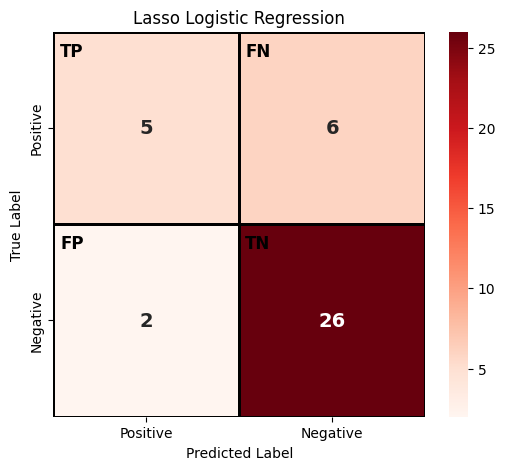

[Ridge Logistic Regression] Sample predicted probabilities: [0.10280235 0.16045176 0.17014856 0.12716412 0.17504315 0.26473439
 0.37119244 0.24169763 0.2486293  0.16055984]
[Ridge Logistic Regression] Applied threshold: 0.353395129431884
[Ridge Logistic Regression] Predicted labels: [False False False False False False  True False False False]
[Ridge Logistic Regression] Sample true values: [0 0 0 1 0 0 1 1 0 0]
[Ridge Logistic Regression] Accuracy: 0.7948717948717948
[Ridge Logistic Regression] F1 Score: 0.5000000000000001


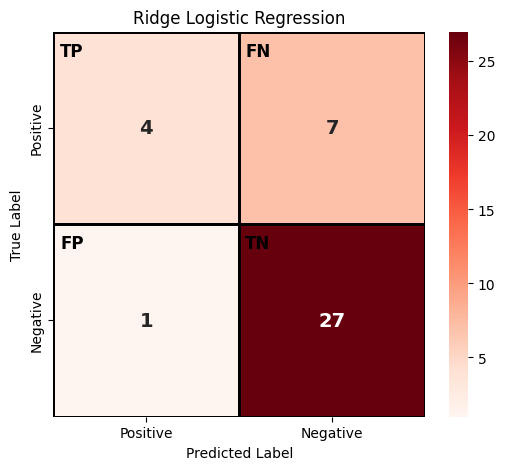

In [1101]:
# Evaluate regression models
print("Regression Models:")
acc_reg_no, f_reg_no = evaluate_model_thresholded_regression(model_reg_no, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Standard Linear Regression", debug=DEBUG_MODE)
acc_reg_l1, f_reg_l1 = evaluate_model_thresholded_regression(model_reg_l1, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Lasso Regression", debug=DEBUG_MODE)
acc_reg_l2, f_reg_l2 = evaluate_model_thresholded_regression(model_reg_l2, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Ridge Regression", debug=DEBUG_MODE)

# Evaluate logistic models
print("Logistic Models:")
acc_log_no, f_log_no = evaluate_model_classifier(model_log_no, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Standard Logistic Regression", debug=DEBUG_MODE)
acc_log_l1, f_log_l1 = evaluate_model_classifier(model_log_l1, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Lasso Logistic Regression", debug=DEBUG_MODE)
acc_log_l2, f_log_l2 = evaluate_model_classifier(model_log_l2, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Ridge Logistic Regression", debug=DEBUG_MODE)

### Analysis

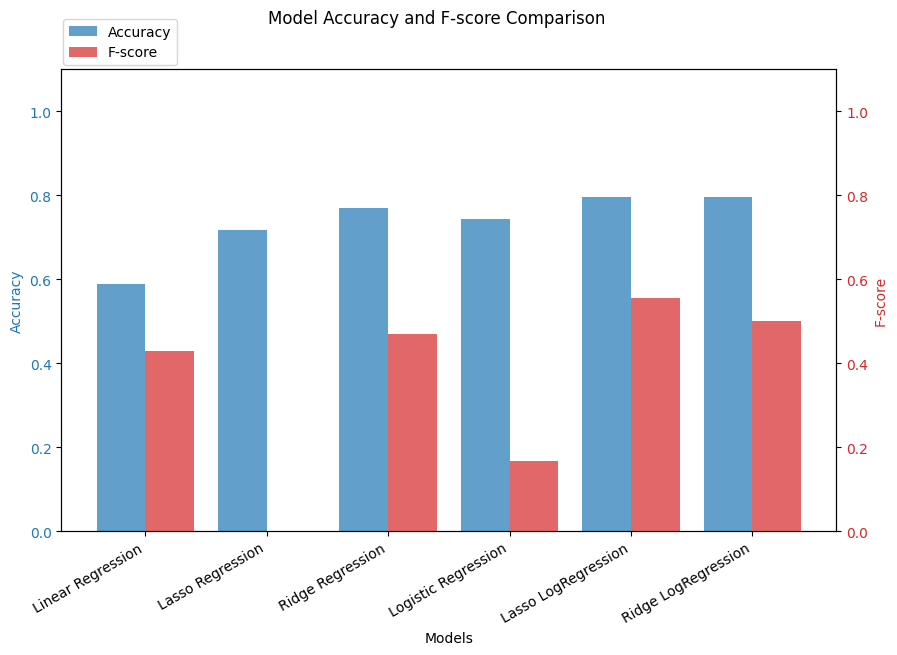

In [1102]:
accs = [acc_reg_no, acc_reg_l1, acc_reg_l2, acc_log_no, acc_log_l1, acc_log_l2]
fscores = [f_reg_no, f_reg_l1, f_reg_l2, f_log_no, f_log_l1, f_log_l2]
model_names = ["Linear Regression", "Lasso Regression", "Ridge Regression",
               "Logistic Regression", "Lasso LogRegression", "Ridge LogRegression"]
plot_model_acc_and_fscore(accs, fscores, model_names)

### Weights

In [1103]:
display_model_weights(model_reg_l1, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

          Feature  Absolute value weight    Weight
8       schoolsup               0.448448 -0.448448
6       studytime               0.442977  0.442977
4            Fedu               0.434642  0.434642
20           Walc               0.298897 -0.298897
9          famsup               0.234714 -0.234714
29    MjobAt_home               0.231285 -0.231285
31      MjobOther               0.217027 -0.217027
39  guardianOther               0.147323 -0.147323
16         famrel               0.136278  0.136278
25     MjobHealth               0.120430  0.120430
Displayed sorted feature weights


In [1104]:
display_model_weights(model_log_l1, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

       Feature  Absolute value weight    Weight
7     failures               0.600187  0.600187
13      higher               0.120017 -0.120017
2      Pstatus               0.000000  0.000000
0      address               0.000000  0.000000
3         Medu               0.000000  0.000000
4         Fedu               0.000000  0.000000
5   traveltime               0.000000  0.000000
1      famsize               0.000000  0.000000
6    studytime               0.000000  0.000000
8    schoolsup               0.000000  0.000000
Displayed sorted feature weights
